<a href="https://colab.research.google.com/github/fcoliveira-utfpr/climas_brasil/blob/main/climas_brasil_series_caracterizacao_UF.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Caracterização das Séries Climáticas Municipais do Brasil (1991-2020)

Este notebook realiza a caracterização espacial e temporal das variáveis climáticas
extraídas do TerraClimate para os municípios brasileiros, cobrindo o período 1991-2020:

- **Tmed** — temperatura média do ar (°C), calculada como a média entre `tmmn` e `tmmx`
- **pr** — precipitação (mm)
- **pet** — evapotranspiração potencial (mm)
- **def** — deficit hídrico climático (mm)



## 1. Configuração do ambiente

In [ ]:
# Instalação de pacotes que normalmente não vêm pré-instalados no Colab
!pip install geobr pymannkendall --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.1/48.1 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.5/21.5 MB 47.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 341.7/341.7 kB 25.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 80.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 95.4 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import geopandas as gpd
import pymannkendall as mk
from matplotlib.colors import TwoSlopeNorm
import warnings

warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid", font_scale=1.05)
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["font.family"] = "DejaVu Sans"

# Paleta e metadados de cada variável — usados de forma consistente em todos os gráficos
VARS = {
    "Tmed":     dict(label="Temperatura média do ar",        unit="°C",     cmap="RdYlBu_r"),
    "pr":       dict(label="Precipitação",                    unit="mm/ano", cmap="YlGnBu"),
    "pet":      dict(label="Evapotranspiração potencial",     unit="mm/ano", cmap="YlOrRd"),
    "deficit":  dict(label="Deficit hídrico climático (def)",  unit="mm/ano", cmap="OrRd"),
}
VAR_ORDER = list(VARS.keys())

## 2. Carregamento dos dados


In [ ]:
import os

CACHE_PATH = "terraclimate_municipios_1991_2020.parquet"
anos = range(1991, 2021)

if os.path.exists(CACHE_PATH):
    df = pd.read_parquet(CACHE_PATH)
    print(f"Dados carregados do cache local: {df.shape}")
else:
    dfs = []
    for ano in anos:
        url = (
            f"https://raw.githubusercontent.com/"
            f"fcoliveira-utfpr/climas_brasil/refs/heads/main/"
            f"terraclimate_serie_mensal_{ano}_municipios_ibge.csv"
        )
        d = pd.read_csv(url)
        d["Ano"] = ano
        dfs.append(d)
        print(f"  ano {ano} carregado ({d.shape[0]} linhas)")

    df = pd.concat(dfs, ignore_index=True)
    df.to_parquet(CACHE_PATH, index=False)
    print(f"\nTotal: {df.shape}")

df.head()

  ano 1991 carregado (66840 linhas)
  ano 1992 carregado (66840 linhas)
  ano 1993 carregado (66840 linhas)
  ano 1994 carregado (66840 linhas)
  ano 1995 carregado (66840 linhas)
  ano 1996 carregado (66840 linhas)
  ano 1997 carregado (66840 linhas)
  ano 1998 carregado (66840 linhas)
  ano 1999 carregado (66840 linhas)
  ano 2000 carregado (66840 linhas)
  ano 2001 carregado (66840 linhas)
  ano 2002 carregado (66840 linhas)
  ano 2003 carregado (66840 linhas)
  ano 2004 carregado (66840 linhas)
  ano 2005 carregado (66840 linhas)
  ano 2006 carregado (66840 linhas)
  ano 2007 carregado (66840 linhas)
  ano 2008 carregado (66840 linhas)
  ano 2009 carregado (66840 linhas)
  ano 2010 carregado (66840 linhas)
  ano 2011 carregado (66840 linhas)
  ano 2012 carregado (66840 linhas)
  ano 2013 carregado (66840 linhas)
  ano 2014 carregado (66840 linhas)
  ano 2015 carregado (66840 linhas)
  ano 2016 carregado (66840 linhas)
  ano 2017 carregado (66840 linhas)
  ano 2018 carregado (66840 

,system:index,aet,ano,def,latitude,longitude,mes,mesorregiao,microrregiao,nome_municipio,...,tmmn,tmmx,uf_nome,uf_sigla,vap,vpd,vs,﻿codigo_ibge,.geo,Ano
0,1_1_1_1_1_1_1_1_1_1_1_0000000000000000144f_0,78.0,1991,0.0,-13.463177,-54.941761,1,NaN,NaN,Boa Esperança do Norte,...,18.4,29.1,NaN,NaN,2.605,0.47,1.56,5101837,"{""geodesic"":false,""type"":""Point"",""coordinates""...",1991
1,1_1_1_1_1_1_1_1_1_1_1_00000000000000000035_0,82.0,1991,0.0,-10.779984,-70.004801,1,Vale do Acre,Brasiléia,Assis Brasil,...,20.8,29.7,Acre,AC,2.620,0.71,1.15,1200054,"{""geodesic"":false,""type"":""Point"",""coordinates""...",1991
2,1_1_1_1_1_1_1_1_1_1_1_00000000000000000036_0,82.0,1991,0.0,-10.747290,-69.207772,1,Vale do Acre,Brasiléia,Brasiléia,...,21.4,29.9,Acre,AC,2.662,0.74,1.25,1200104,"{""geodesic"":false,""type"":""Point"",""coordinates""...",1991
3,1_1_1_1_1_1_1_1_1_1_1_0000000000000000003a_0,81.6,1991,0.0,-10.889125,-68.618257,1,Vale do Acre,Brasiléia,Epitaciolândia,...,21.9,30.2,Acre,AC,2.725,0.75,1.35,1200252,"{""geodesic"":false,""type"":""Point"",""coordinates""...",1991
4,1_1_1_1_1_1_1_1_1_1_1_00000000000000000048_0,79.9,1991,0.0,-10.575534,-68.505067,1,Vale do Acre,Brasiléia,Xapuri,...,21.8,29.8,Acre,AC,2.744,0.68,1.26,1200708,"{""geodesic"":false,""type"":""Point"",""coordinates""...",1991


## 3. Limpeza e preparação

Três correções são necessárias antes da análise:

1. A coluna de código IBGE vem com um caractere BOM invisível no nome (`\ufeffcodigo_ibge`) — renomeada para `codigo_ibge`.
2. Uma pequena fração dos municípios chega sem `uf_sigla`/`uf_nome` preenchidos. Como o código IBGE de 7 dígitos
   traz o código da UF nos dois primeiros dígitos, a informação é reconstruída de forma determinística — sem perda de linhas.
3. Criação da **Tmed** (temperatura média) a partir de `tmmn` e `tmmx`.

In [ ]:
# 3.1 Corrige o nome da coluna de código IBGE (BOM)
bom_col = [c for c in df.columns if "codigo_ibge" in c][0]
df = df.rename(columns={bom_col: "codigo_ibge", "def": "deficit"})

# 3.2 Reconstrói uf_sigla / uf_nome a partir do prefixo do código IBGE
UF_POR_CODIGO = {
    "11": ("RO", "Rondônia"), "12": ("AC", "Acre"), "13": ("AM", "Amazonas"),
    "14": ("RR", "Roraima"), "15": ("PA", "Pará"), "16": ("AP", "Amapá"),
    "17": ("TO", "Tocantins"), "21": ("MA", "Maranhão"), "22": ("PI", "Piauí"),
    "23": ("CE", "Ceará"), "24": ("RN", "Rio Grande do Norte"), "25": ("PB", "Paraíba"),
    "26": ("PE", "Pernambuco"), "27": ("AL", "Alagoas"), "28": ("SE", "Sergipe"),
    "29": ("BA", "Bahia"), "31": ("MG", "Minas Gerais"), "32": ("ES", "Espírito Santo"),
    "33": ("RJ", "Rio de Janeiro"), "35": ("SP", "São Paulo"), "41": ("PR", "Paraná"),
    "42": ("SC", "Santa Catarina"), "43": ("RS", "Rio Grande do Sul"),
    "50": ("MS", "Mato Grosso do Sul"), "51": ("MT", "Mato Grosso"),
    "52": ("GO", "Goiás"), "53": ("DF", "Distrito Federal"),
}
REGIAO_POR_UF = {
    **{s: "Norte" for s in ["RO", "AC", "AM", "RR", "PA", "AP", "TO"]},
    **{s: "Nordeste" for s in ["MA", "PI", "CE", "RN", "PB", "PE", "AL", "SE", "BA"]},
    **{s: "Sudeste" for s in ["MG", "ES", "RJ", "SP"]},
    **{s: "Sul" for s in ["PR", "SC", "RS"]},
    **{s: "Centro-Oeste" for s in ["MS", "MT", "GO", "DF"]},
}

prefixo = df["codigo_ibge"].astype(str).str[:2]
df["uf_sigla"] = prefixo.map(lambda x: UF_POR_CODIGO.get(x, (None, None))[0])
df["uf_nome"] = prefixo.map(lambda x: UF_POR_CODIGO.get(x, (None, None))[1])
df["regiao_nome"] = df["uf_sigla"].map(REGIAO_POR_UF)

print(f"Municípios sem UF identificada após correção: {df['uf_sigla'].isna().sum()}")

# 3.3 Temperatura média
df["Tmed"] = (df["tmmn"] + df["tmmx"]) / 2

# Colunas de trabalho
cols_id = ["codigo_ibge", "nome_municipio", "uf_sigla", "uf_nome", "regiao_nome",
           "latitude", "longitude", "Ano", "mes"]
cols_var = ["Tmed", "pr", "pet", "deficit"]
df = df[cols_id + cols_var].rename(columns={"Ano": "ano"})
df.head()

Municípios sem UF identificada após correção: 0


,codigo_ibge,nome_municipio,uf_sigla,uf_nome,regiao_nome,latitude,longitude,ano,mes,Tmed,pr,pet,deficit
0,5101837,Boa Esperança do Norte,MT,Mato Grosso,Centro-Oeste,-13.463177,-54.941761,1991,1,23.75,287.0,78.0,0.0
1,1200054,Assis Brasil,AC,Acre,Norte,-10.779984,-70.004801,1991,1,25.25,279.0,82.0,0.0
2,1200104,Brasiléia,AC,Acre,Norte,-10.747290,-69.207772,1991,1,25.65,294.0,82.0,0.0
3,1200252,Epitaciolândia,AC,Acre,Norte,-10.889125,-68.618257,1991,1,26.05,342.0,81.6,0.0
4,1200708,Xapuri,AC,Acre,Norte,-10.575534,-68.505067,1991,1,25.80,370.0,79.9,0.0


## 4. Agregação anual e normal climatológica (1991-2020)

- **Tmed**: agregada como *média* anual (é uma variável de estado, não acumulada).
- **pr, pet, deficit**: agregadas como *soma* anual (fluxos hídricos mensais em mm).

A **normal climatológica** de cada município é a média das 30 agregações anuais

In [ ]:
agg_anual = (
    df.groupby(["codigo_ibge", "nome_municipio", "uf_sigla", "uf_nome", "regiao_nome",
                 "latitude", "longitude", "ano"])
    .agg(Tmed=("Tmed", "mean"), pr=("pr", "sum"), pet=("pet", "sum"), deficit=("deficit", "sum"))
    .reset_index()
)

normal = (
    agg_anual.groupby(["codigo_ibge", "nome_municipio", "uf_sigla", "uf_nome", "regiao_nome",
                        "latitude", "longitude"])[VAR_ORDER]
    .mean()
    .reset_index()
)

print(f"Agregação anual: {agg_anual.shape[0]} registros (município x ano)")
print(f"Normal climatológica: {normal.shape[0]} municípios")
normal.describe().round(1)

Agregação anual: 167100 registros (município x ano)
Normal climatológica: 5570 municípios


,codigo_ibge,latitude,longitude,Tmed,pr,pet,deficit
count,5570.0,5570.0,5570.0,5570.0,5570.0,5570.0,5570.0
mean,3253931.3,-16.5,-46.3,22.7,1362.1,1270.3,374.5
std,985221.4,8.3,6.4,2.9,462.3,166.8,277.9
min,1100015.0,-33.7,-73.4,13.8,280.6,883.8,2.1
25%,2512125.8,-22.8,-50.9,20.3,1083.8,1143.1,164.6
50%,3146280.0,-18.1,-46.5,22.9,1400.2,1269.8,305.0
75%,4119238.8,-8.5,-41.4,25.1,1632.4,1373.7,500.0
max,5300108.0,4.7,-32.4,28.4,3680.5,1748.8,1302.5


## 5. Análise espacial — caracterização por estado

### 5.1 Estatística descritiva por UF

Média, desvio-padrão e amplitude (máximo − mínimo) das normais climatológicas municipais
dentro de cada estado. O desvio-padrão intraestadual funciona como medida de
**heterogeneidade climática interna** — estados grandes e com relevo variado
(ex. BA, MG, MT) tendem a apresentar maior dispersão do que estados pequenos e mais homogêneos.

In [ ]:
estado_stats = (
    normal.groupby("uf_sigla")[VAR_ORDER]
    .agg(["mean", "std", "min", "max"])
    .round(2)
)
estado_stats.columns = ["_".join(c) for c in estado_stats.columns]
estado_stats = estado_stats.sort_values("Tmed_mean", ascending=False)
estado_stats

,Tmed_mean,Tmed_std,Tmed_min,Tmed_max,pr_mean,pr_std,pr_min,pr_max,pet_mean,pet_std,pet_min,pet_max,deficit_mean,deficit_std,deficit_min,deficit_max
uf_sigla,,,,,,,,,,,,,,,,
MA,27.07,0.75,24.59,28.44,1576.21,391.22,972.70,2956.07,1417.23,64.37,1298.21,1562.45,383.62,125.11,154.53,686.34
RR,26.98,0.99,24.29,28.17,2054.63,255.58,1663.77,2559.80,1321.91,50.98,1224.35,1410.81,197.43,82.44,81.34,376.01
AM,26.91,0.71,25.05,27.91,2477.75,338.94,2095.90,3680.47,1124.49,63.65,1012.49,1254.22,70.57,42.12,2.13,143.26
PI,26.71,0.81,24.18,28.42,958.28,307.84,417.10,1632.57,1544.33,41.22,1399.83,1619.89,755.84,215.50,388.04,1226.56
PA,26.54,0.52,24.04,27.60,2353.17,480.83,1524.87,3556.13,1303.37,48.64,1157.18,1387.93,208.25,53.69,87.45,364.99
AP,26.52,0.53,25.62,27.19,2353.99,178.71,1994.73,2721.23,1348.70,34.32,1282.41,1419.19,187.61,43.84,137.63,260.95
CE,26.01,1.47,21.06,27.90,891.33,200.68,523.13,1512.00,1553.97,75.68,1286.03,1705.86,839.37,151.59,357.05,1086.14
TO,25.85,0.63,23.63,27.16,1563.03,135.84,1210.73,1824.73,1366.56,46.19,1287.43,1510.00,394.64,74.57,286.93,579.45
RN,25.79,1.04,22.34,27.98,760.35,222.31,451.90,1438.63,1528.04,87.22,1332.41,1748.76,869.64,176.18,444.39,1124.21


### 5.2 Distribuição por estado (boxplots)

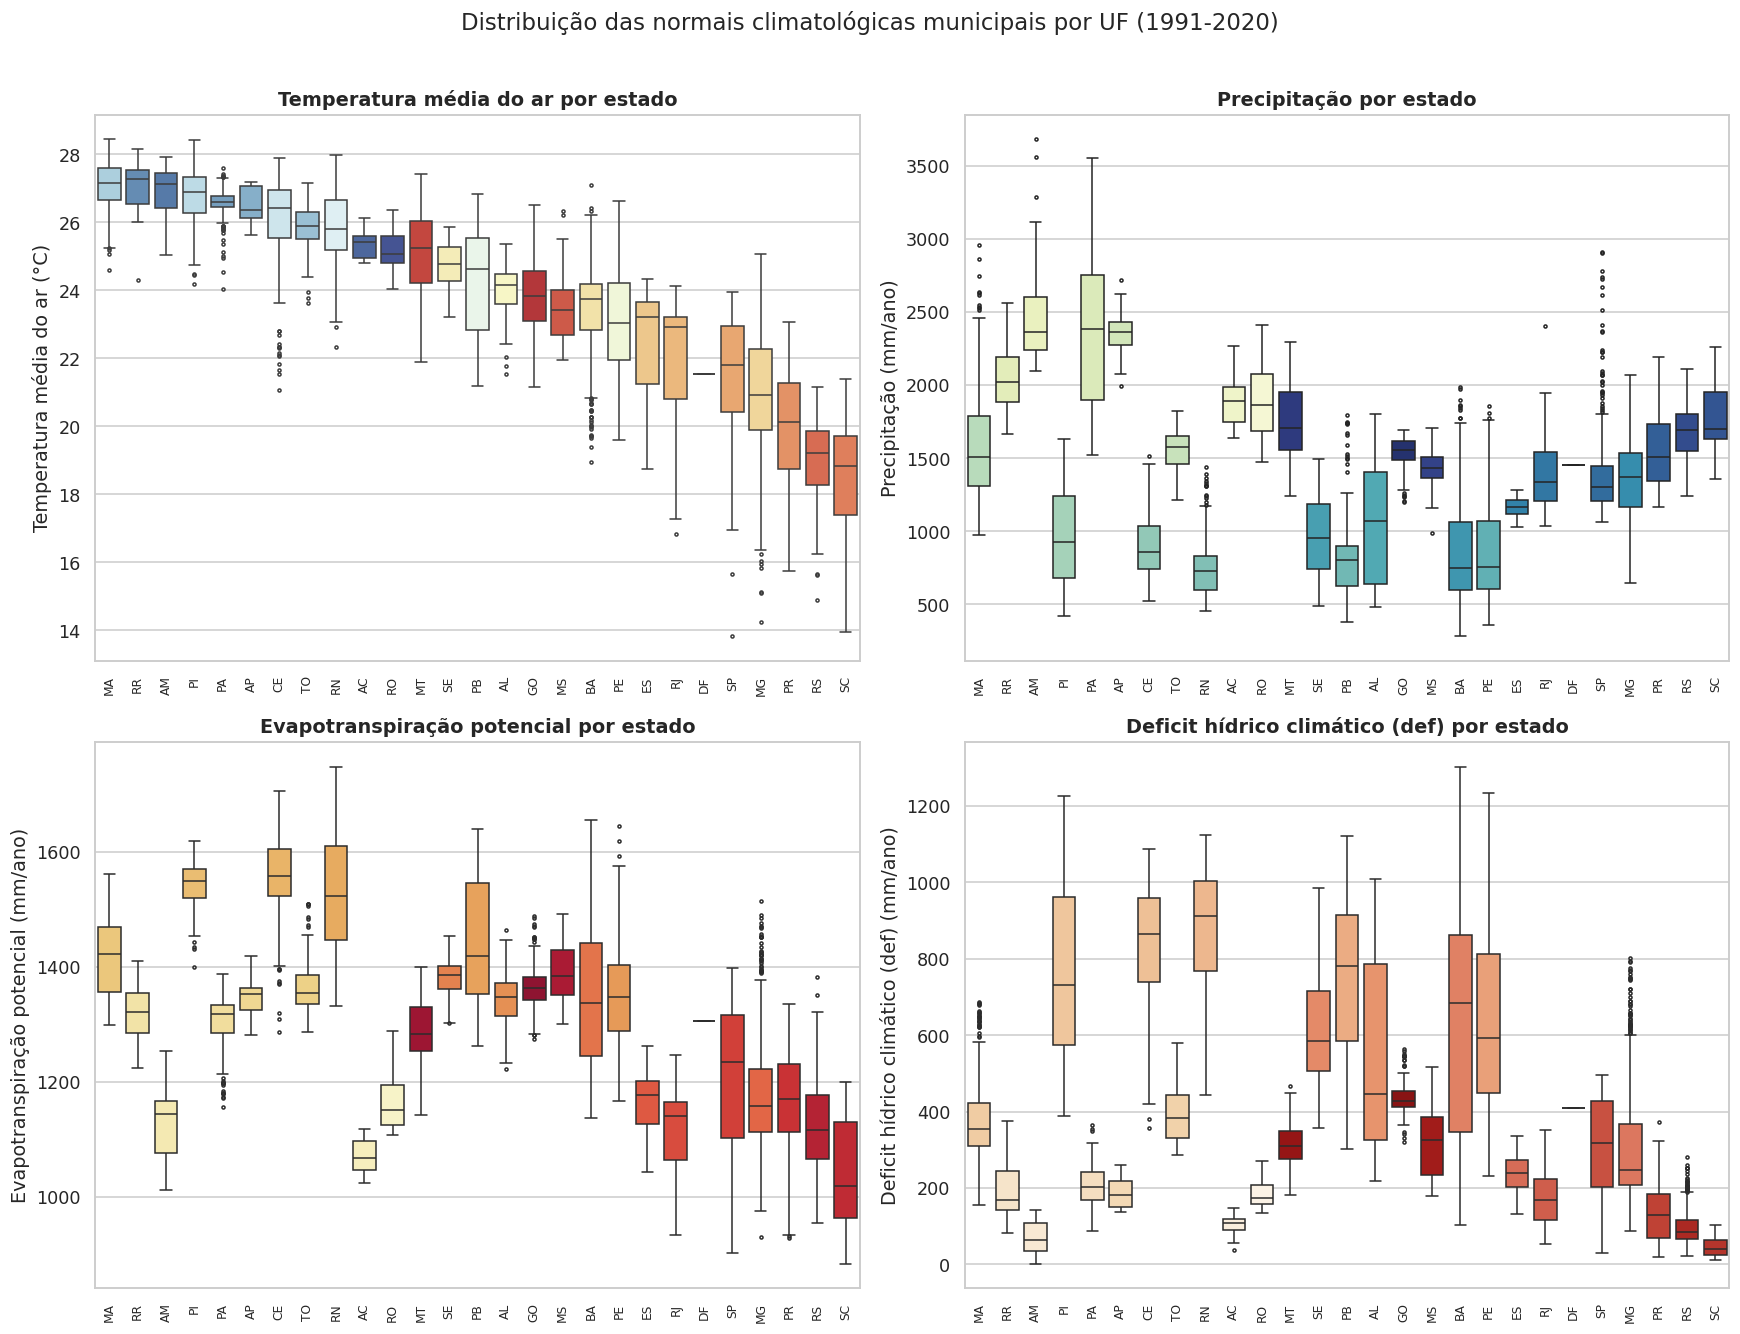

In [ ]:
ordem_uf = normal.groupby("uf_sigla")["Tmed"].mean().sort_values(ascending=False).index

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
for ax, var in zip(axes.flat, VAR_ORDER):
    meta = VARS[var]
    sns.boxplot(
        data=normal, x="uf_sigla", y=var, order=ordem_uf, ax=ax,
        palette=meta["cmap"], hue="uf_sigla", legend=False, showfliers=True, fliersize=2,
    )
    ax.set_title(f"{meta['label']} por estado")
    ax.set_xlabel("")
    ax.set_ylabel(f"{meta['label']} ({meta['unit']})")
    ax.tick_params(axis="x", rotation=90, labelsize=8)

fig.suptitle("Distribuição das normais climatológicas municipais por UF (1991-2020)",
             fontsize=15, y=1.01)
fig.tight_layout()
plt.show()

### 5.3 Heatmap comparativo entre estados (variáveis padronizadas)

Como as quatro variáveis têm escalas e unidades distintas, cada coluna é padronizada
(*z-score* entre estados) para permitir comparação direta em um único painel.
Valores positivos (vermelho) indicam estado acima da média nacional; negativos (azul), abaixo.

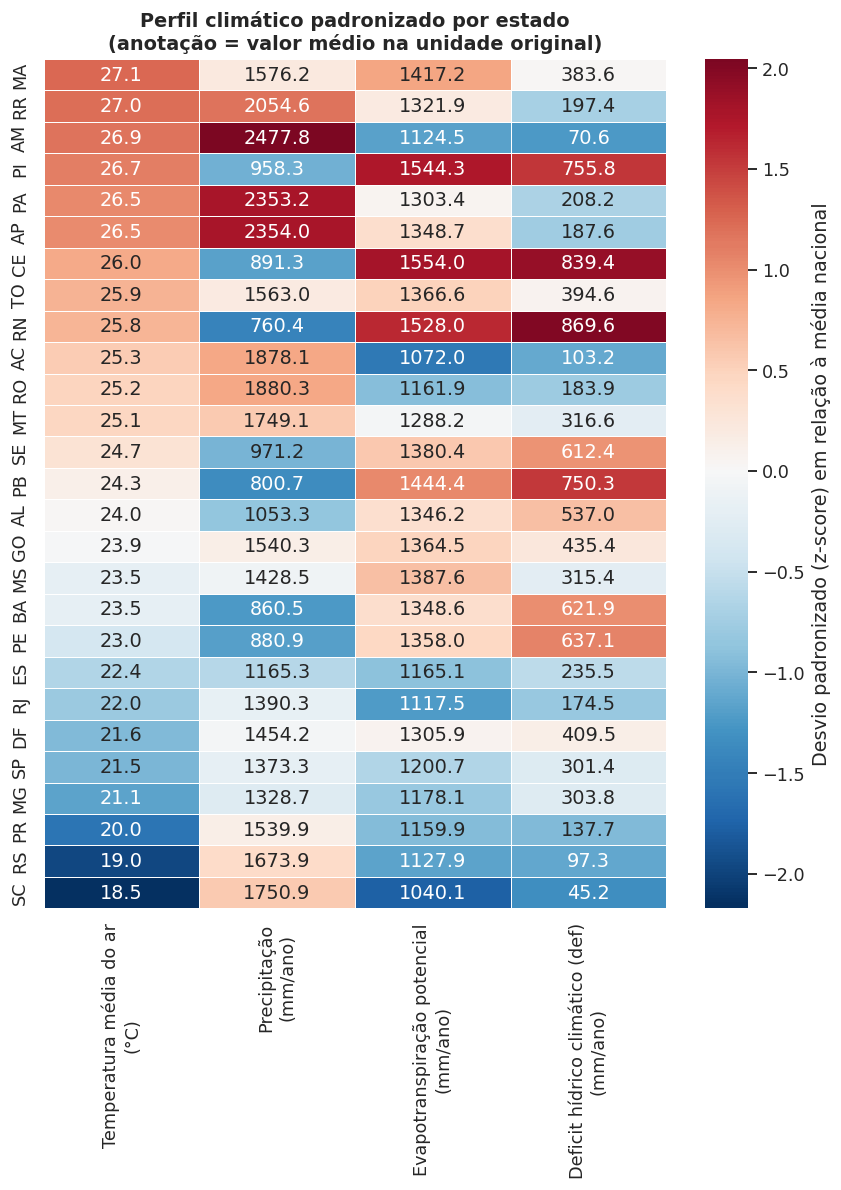

In [ ]:
medias_uf = normal.groupby("uf_sigla")[VAR_ORDER].mean()
z_uf = (medias_uf - medias_uf.mean()) / medias_uf.std()
z_uf = z_uf.loc[ordem_uf]
z_uf.columns = [f"{VARS[v]['label']}\n({VARS[v]['unit']})" for v in z_uf.columns]

fig, ax = plt.subplots(figsize=(8, 11))
sns.heatmap(
    z_uf, cmap="RdBu_r", center=0, annot=medias_uf.loc[ordem_uf].round(1).values,
    fmt="", cbar_kws={"label": "Desvio padronizado (z-score) em relação à média nacional"},
    linewidths=0.4, linecolor="white", ax=ax,
)
ax.set_title("Perfil climático padronizado por estado\n(anotação = valor médio na unidade original)")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

### 5.4 Mapas coropléticos por estado

Tenta usar o `geobr` (fonte oficial IBGE/IPEA). Caso a API esteja indisponível
(situação já observada em execuções anteriores), recorre a uma malha estadual
simplificada hospedada no GitHub como *fallback* automático.

In [ ]:
def carregar_malha_estados():
    try:
        import geobr
        gdf = geobr.read_state(year=2020)
        gdf = gdf.rename(columns={"abbrev_state": "uf_sigla"})[["uf_sigla", "geometry"]]
        print("Malha estadual carregada via geobr.")
        return gdf
    except Exception as e:
        print(f"geobr indisponível ({type(e).__name__}: {e}). Usando malha alternativa (fallback)...")
        import requests, io
        url_fallback = "https://raw.githubusercontent.com/giuliano-macedo/geodata-br-states/main/geojson/br_states.json"
        # Baixa via requests (mais robusto a proxies/SSL do que o leitor HTTP interno do geopandas)
        resp = requests.get(url_fallback, timeout=30)
        gdf = gpd.read_file(io.BytesIO(resp.content)).rename(columns={"SIGLA": "uf_sigla"})[["uf_sigla", "geometry"]]
        print("Malha estadual carregada via fallback (GitHub).")
        return gdf

gdf_uf = carregar_malha_estados()
gdf_uf_stats = gdf_uf.merge(medias_uf.reset_index(), on="uf_sigla", how="left")
gdf_uf_stats.plot(column="Tmed"); plt.close()  # smoke test
print(gdf_uf_stats.shape)

states_2020_simplified.parquet: 100%|██████████| 1.72M/1.72M [00:00<00:00, 30.1MB/s]


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Malha estadual carregada via geobr.
(27, 6)


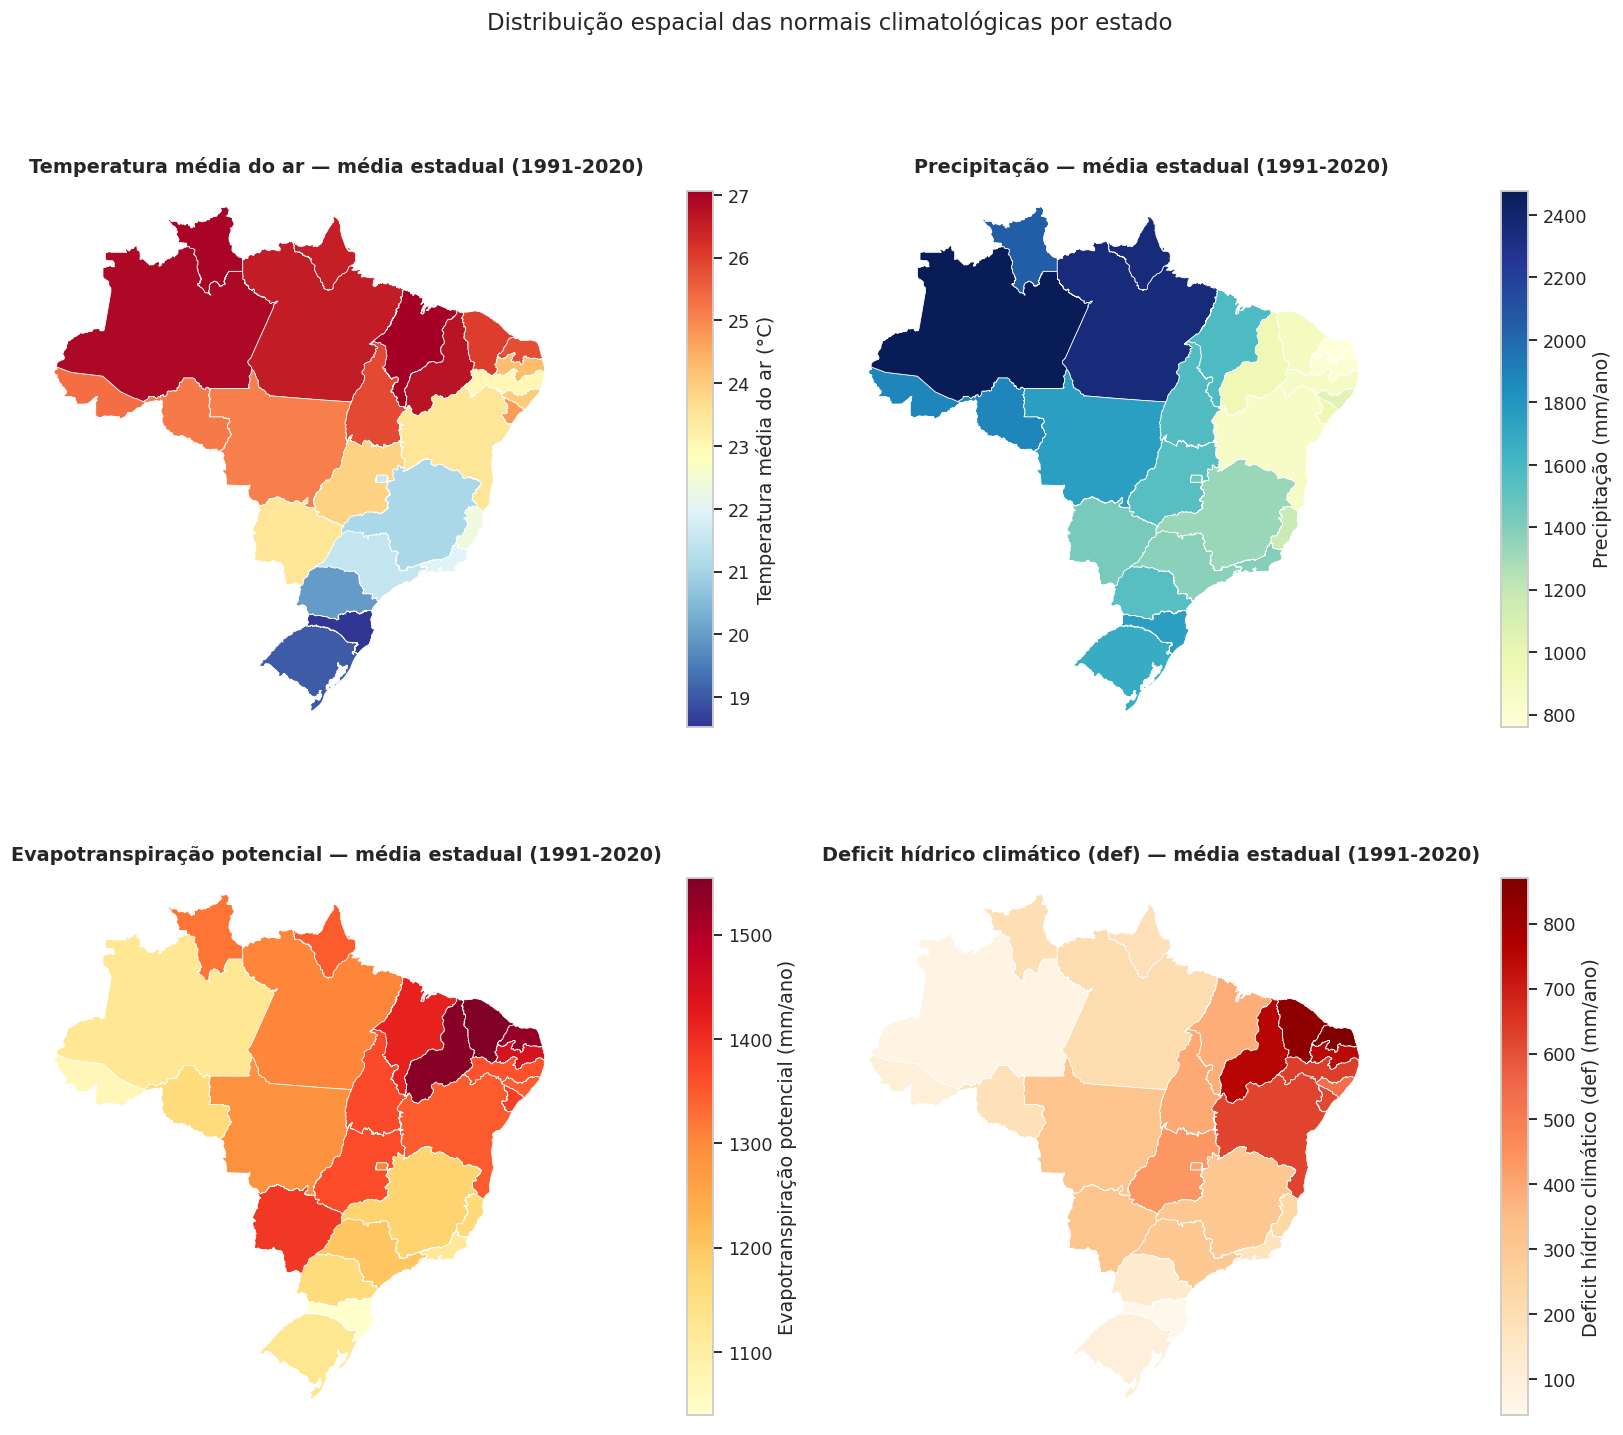

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(15, 14))
for ax, var in zip(axes.flat, VAR_ORDER):
    meta = VARS[var]
    gdf_uf_stats.plot(
        column=var, cmap=meta["cmap"], legend=True, ax=ax,
        edgecolor="white", linewidth=0.5,
        legend_kwds={"label": f"{meta['label']} ({meta['unit']})", "shrink": 0.7},
    )
    ax.set_title(f"{meta['label']} — média estadual (1991-2020)")
    ax.axis("off")

fig.suptitle("Distribuição espacial das normais climatológicas por estado", fontsize=15, y=1.0)
fig.tight_layout()
plt.show()

### 5.5 Municípios extremos e anomalias intraestaduais

Para identificar cidades climaticamente "atípicas" dentro do próprio estado, calcula-se
o z-score de cada município em relação à média e ao desvio-padrão do seu estado —
isso evita que a comparação seja dominada apenas pela variabilidade latitudinal do país
(ex. comparar diretamente uma cidade do RS com uma do AM não é informativo; compará-la
com a média do RS, sim).

In [ ]:
for var in VAR_ORDER:
    normal[f"{var}_z_uf"] = normal.groupby("uf_sigla")[var].transform(
        lambda s: (s - s.mean()) / s.std(ddof=0) if s.std(ddof=0) > 0 else 0.0
    )

def top_extremos(var, n=5):
    meta = VARS[var]
    col_z = f"{var}_z_uf"
    maiores = normal.nlargest(n, var)[["nome_municipio", "uf_sigla", var]]
    menores = normal.nsmallest(n, var)[["nome_municipio", "uf_sigla", var]]
    anomalos_pos = normal.nlargest(n, col_z)[["nome_municipio", "uf_sigla", var, col_z]]
    anomalos_neg = normal.nsmallest(n, col_z)[["nome_municipio", "uf_sigla", var, col_z]]
    print(f"\n{'='*70}\n{meta['label']} ({meta['unit']})\n{'='*70}")
    print(f"\n-- Top {n} maiores valores absolutos (Brasil) --")
    print(maiores.to_string(index=False))
    print(f"\n-- Top {n} menores valores absolutos (Brasil) --")
    print(menores.to_string(index=False))
    print(f"\n-- Top {n} anomalias positivas (mais destoantes acima da média do próprio estado) --")
    print(anomalos_pos.to_string(index=False))
    print(f"\n-- Top {n} anomalias negativas (mais destoantes abaixo da média do próprio estado) --")
    print(anomalos_neg.to_string(index=False))

for var in VAR_ORDER:
    top_extremos(var, n=5)


Temperatura média do ar (°C)

-- Top 5 maiores valores absolutos (Brasil) --
              nome_municipio uf_sigla      Tmed
                     Bacabal       MA 28.443611
                    Teresina       PI 28.417361
São Luís Gonzaga do Maranhão       MA 28.364444
      São Mateus do Maranhão       MA 28.353056
                     Coroatá       MA 28.256250

-- Top 5 menores valores absolutos (Brasil) --
     nome_municipio uf_sigla      Tmed
   Campos do Jordão       SP 13.815278
            Urubici       SC 13.931528
           Itamonte       MG 14.231667
Bom Jardim da Serra       SC 14.255972
            Urupema       SC 14.562083

-- Top 5 anomalias positivas (mais destoantes acima da média do próprio estado) --
     nome_municipio uf_sigla      Tmed  Tmed_z_uf
            Ladário       MS 26.344861   2.827433
            Remanso       BA 27.109583   2.752389
            Corumbá       MS 26.224444   2.707908
Fernando de Noronha       PE 26.638472   2.474010
          Juveníli

### 5.6 Mapa dos extremos municipais sobre a malha estadual

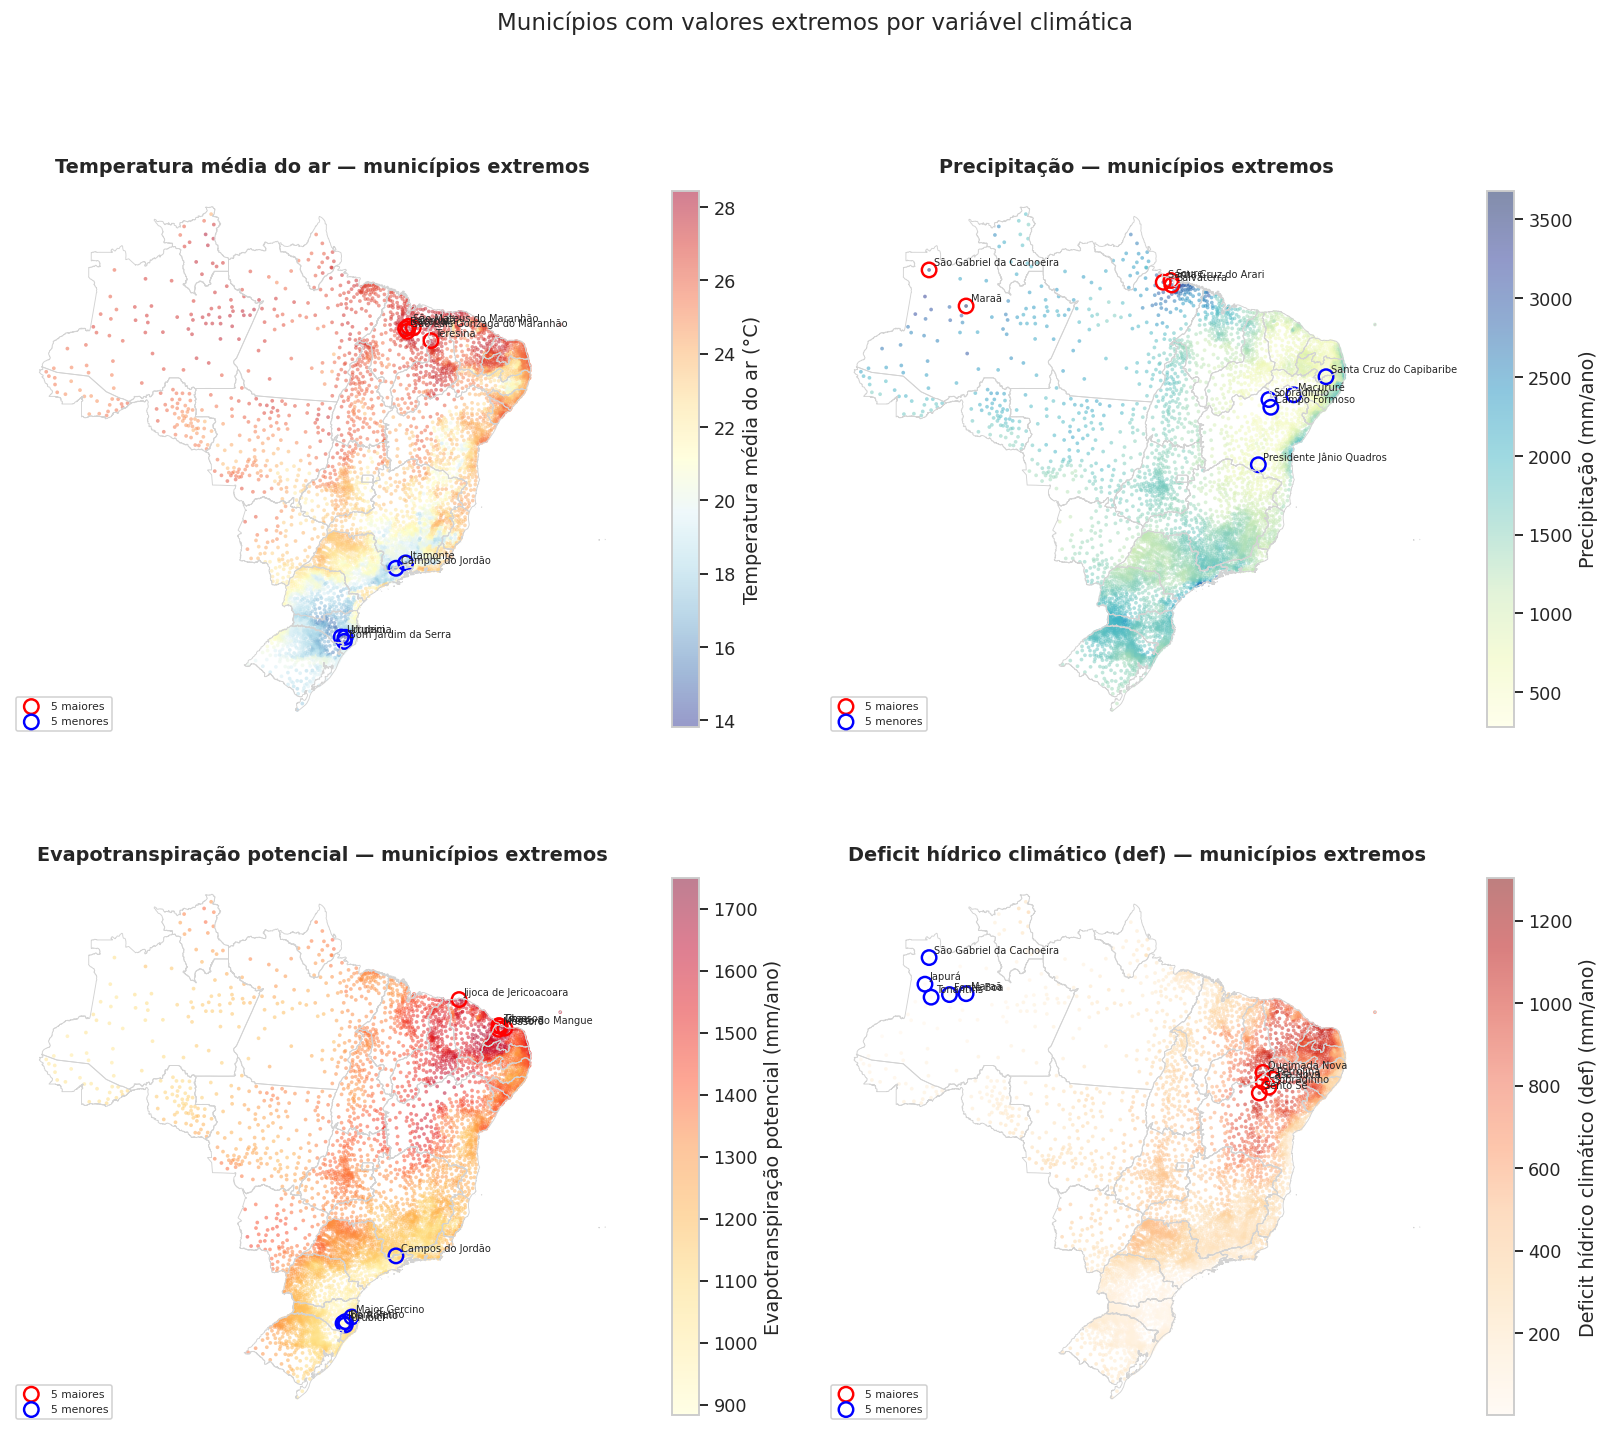

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(15, 14))
for ax, var in zip(axes.flat, VAR_ORDER):
    meta = VARS[var]
    gdf_uf.boundary.plot(ax=ax, color="lightgray", linewidth=0.6)

    sc = ax.scatter(
        normal["longitude"], normal["latitude"], c=normal[var], cmap=meta["cmap"],
        s=6, alpha=0.5, linewidths=0,
    )

    top5 = normal.nlargest(5, var)
    bot5 = normal.nsmallest(5, var)
    ax.scatter(top5["longitude"], top5["latitude"], facecolor="none",
               edgecolor="red", s=90, linewidth=1.6, label="5 maiores")
    ax.scatter(bot5["longitude"], bot5["latitude"], facecolor="none",
               edgecolor="blue", s=90, linewidth=1.6, label="5 menores")
    for _, row in pd.concat([top5, bot5]).iterrows():
        ax.annotate(row["nome_municipio"], (row["longitude"], row["latitude"]),
                    fontsize=6.5, xytext=(3, 3), textcoords="offset points")

    plt.colorbar(sc, ax=ax, shrink=0.7, label=f"{meta['label']} ({meta['unit']})")
    ax.set_title(f"{meta['label']} — municípios extremos")
    ax.legend(loc="lower left", fontsize=7, framealpha=0.9)
    ax.axis("off")

fig.suptitle("Municípios com valores extremos por variável climática", fontsize=15, y=1.0)
fig.tight_layout()
plt.show()

## 6. Análise temporal

### 6.1 Ciclo sazonal médio nacional

Média mensal de cada variável, calculada sobre todos os municípios e todos os anos
(1991-2020), representando o comportamento climatológico sazonal típico do Brasil.

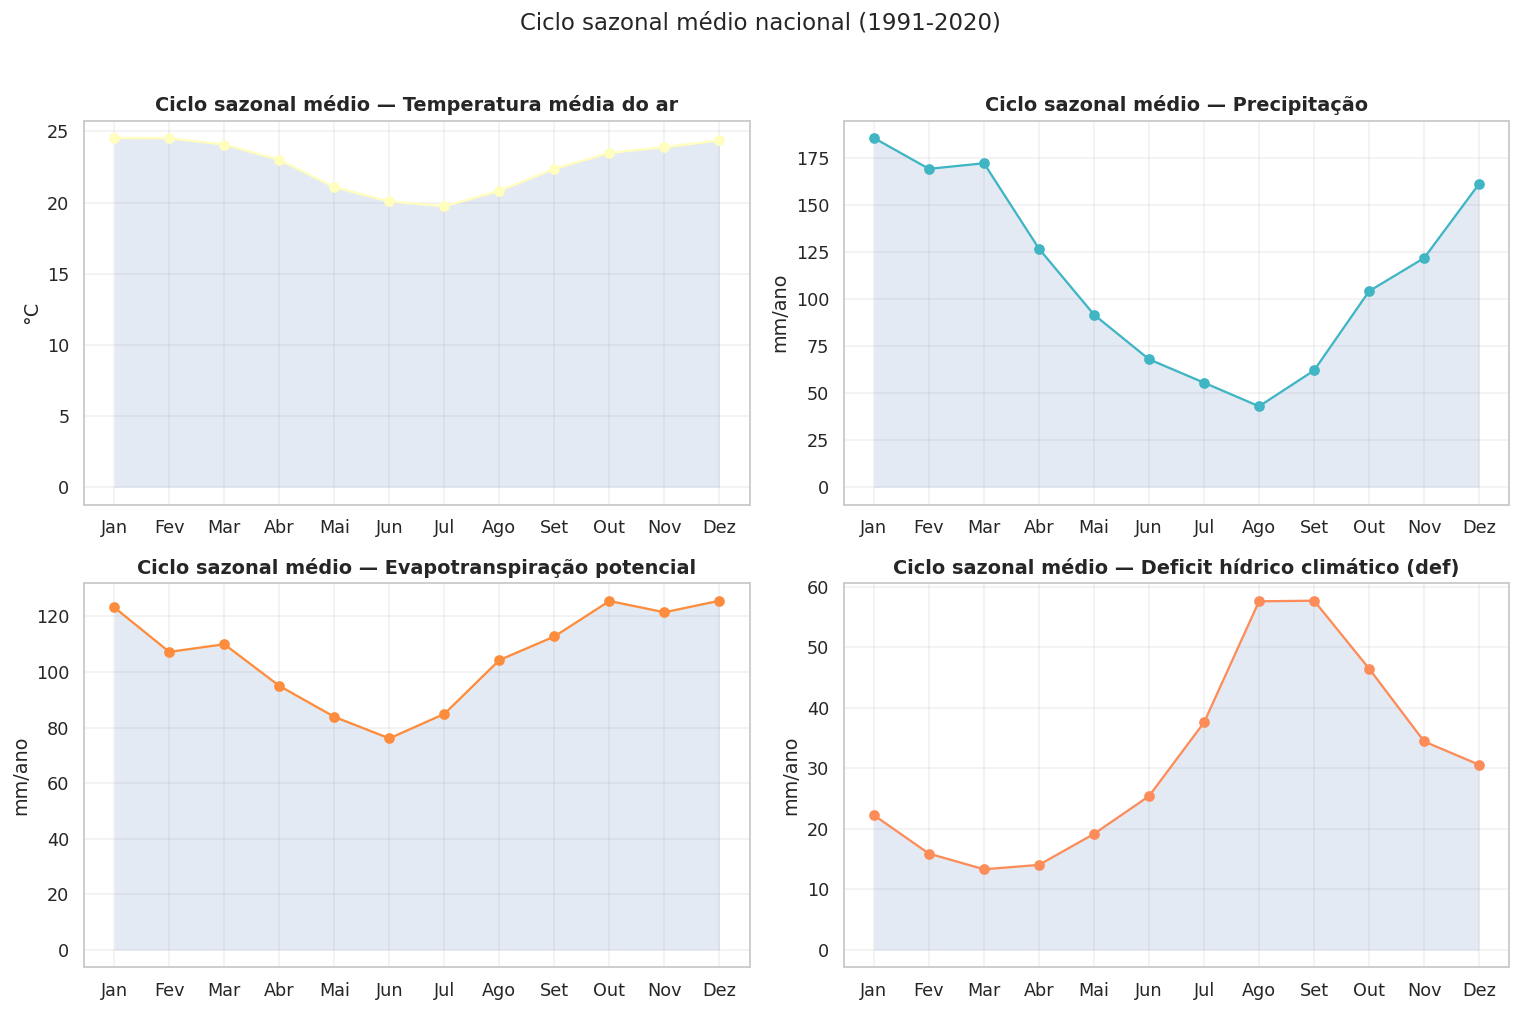

In [ ]:
ciclo_sazonal = df.groupby("mes")[VAR_ORDER].mean()
meses_lbl = ["Jan","Fev","Mar","Abr","Mai","Jun","Jul","Ago","Set","Out","Nov","Dez"]

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
for ax, var in zip(axes.flat, VAR_ORDER):
    meta = VARS[var]
    ax.plot(meses_lbl, ciclo_sazonal[var], marker="o", color=sns.color_palette(meta["cmap"], 1)[0])
    ax.fill_between(meses_lbl, ciclo_sazonal[var], alpha=0.15)
    ax.set_title(f"Ciclo sazonal médio — {meta['label']}")
    ax.set_ylabel(meta["unit"])
    ax.grid(alpha=0.3)

fig.suptitle("Ciclo sazonal médio nacional (1991-2020)", fontsize=15, y=1.02)
fig.tight_layout()
plt.show()

### 6.2 Heatmap ano x mês (nível nacional)

Permite visualizar simultaneamente a sazonalidade (eixo horizontal) e a variabilidade
interanual (eixo vertical), incluindo eventuais sinais de tendência de longo prazo.

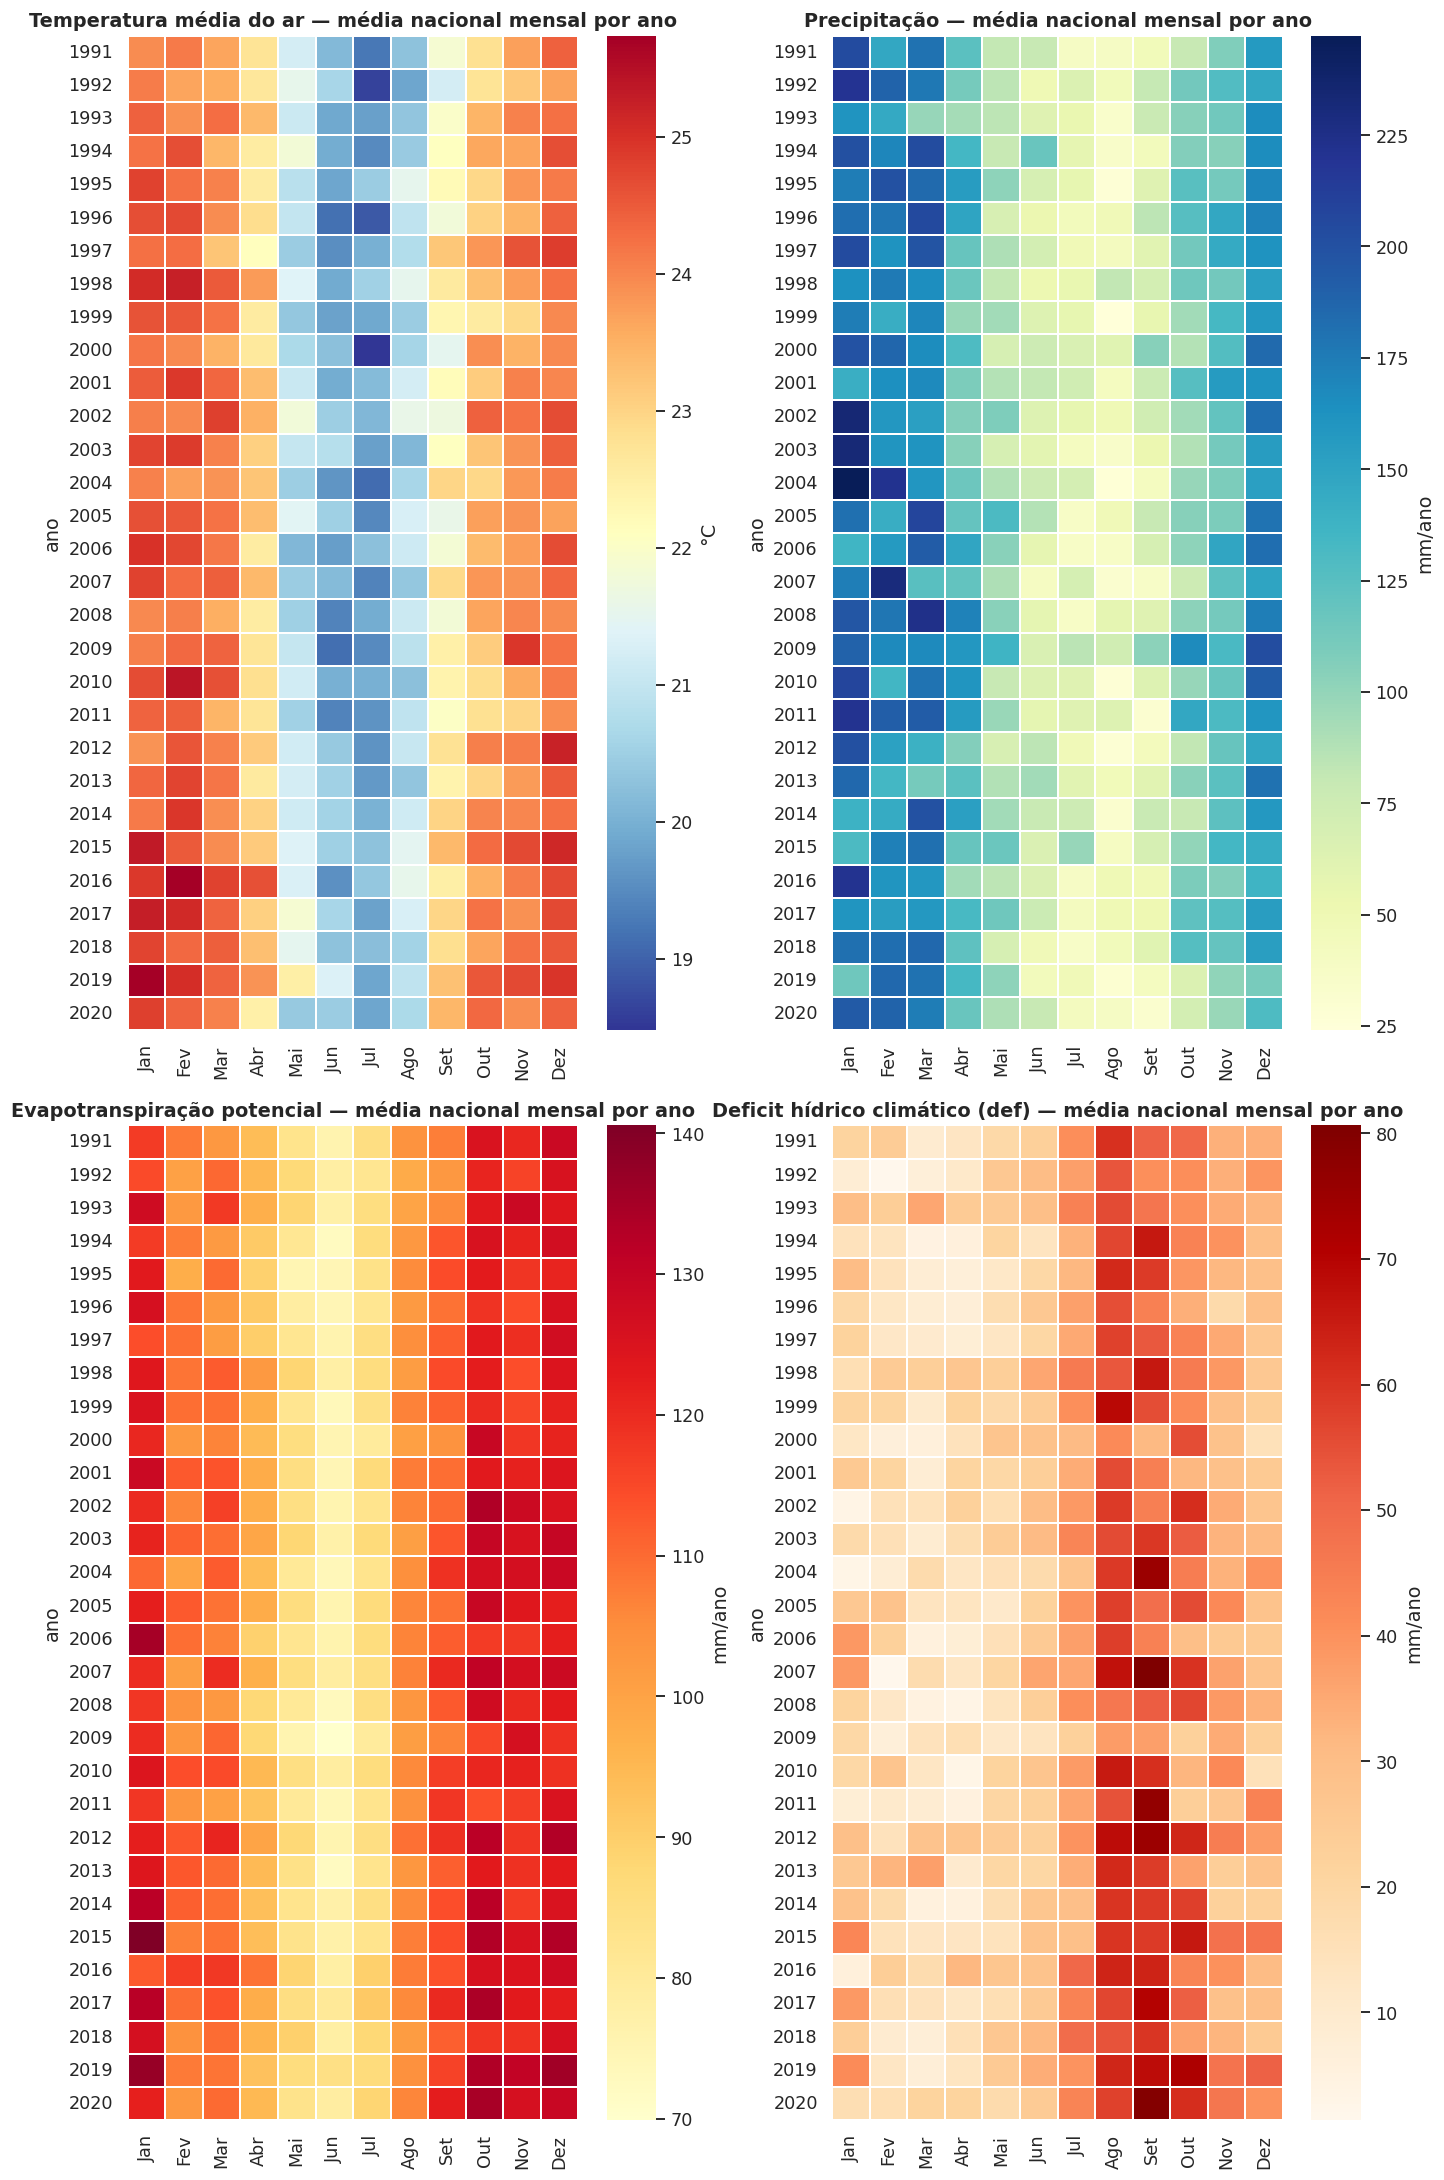

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(13, 20))
for ax, var in zip(axes.flat, VAR_ORDER):
    meta = VARS[var]
    pivot = df.pivot_table(index="ano", columns="mes", values=var, aggfunc="mean")
    pivot.columns = meses_lbl
    sns.heatmap(pivot, cmap=meta["cmap"], ax=ax, cbar_kws={"label": meta["unit"]}, linewidths=0.2)
    ax.set_title(f"{meta['label']} — média nacional mensal por ano")
    ax.set_xlabel("")

fig.tight_layout()
plt.show()

### 6.3 Séries temporais anuais por estado

Evolução da média anual de cada variável para cada uma das 27 UFs (pequenos múltiplos),
com a média nacional destacada em cada painel como referência.

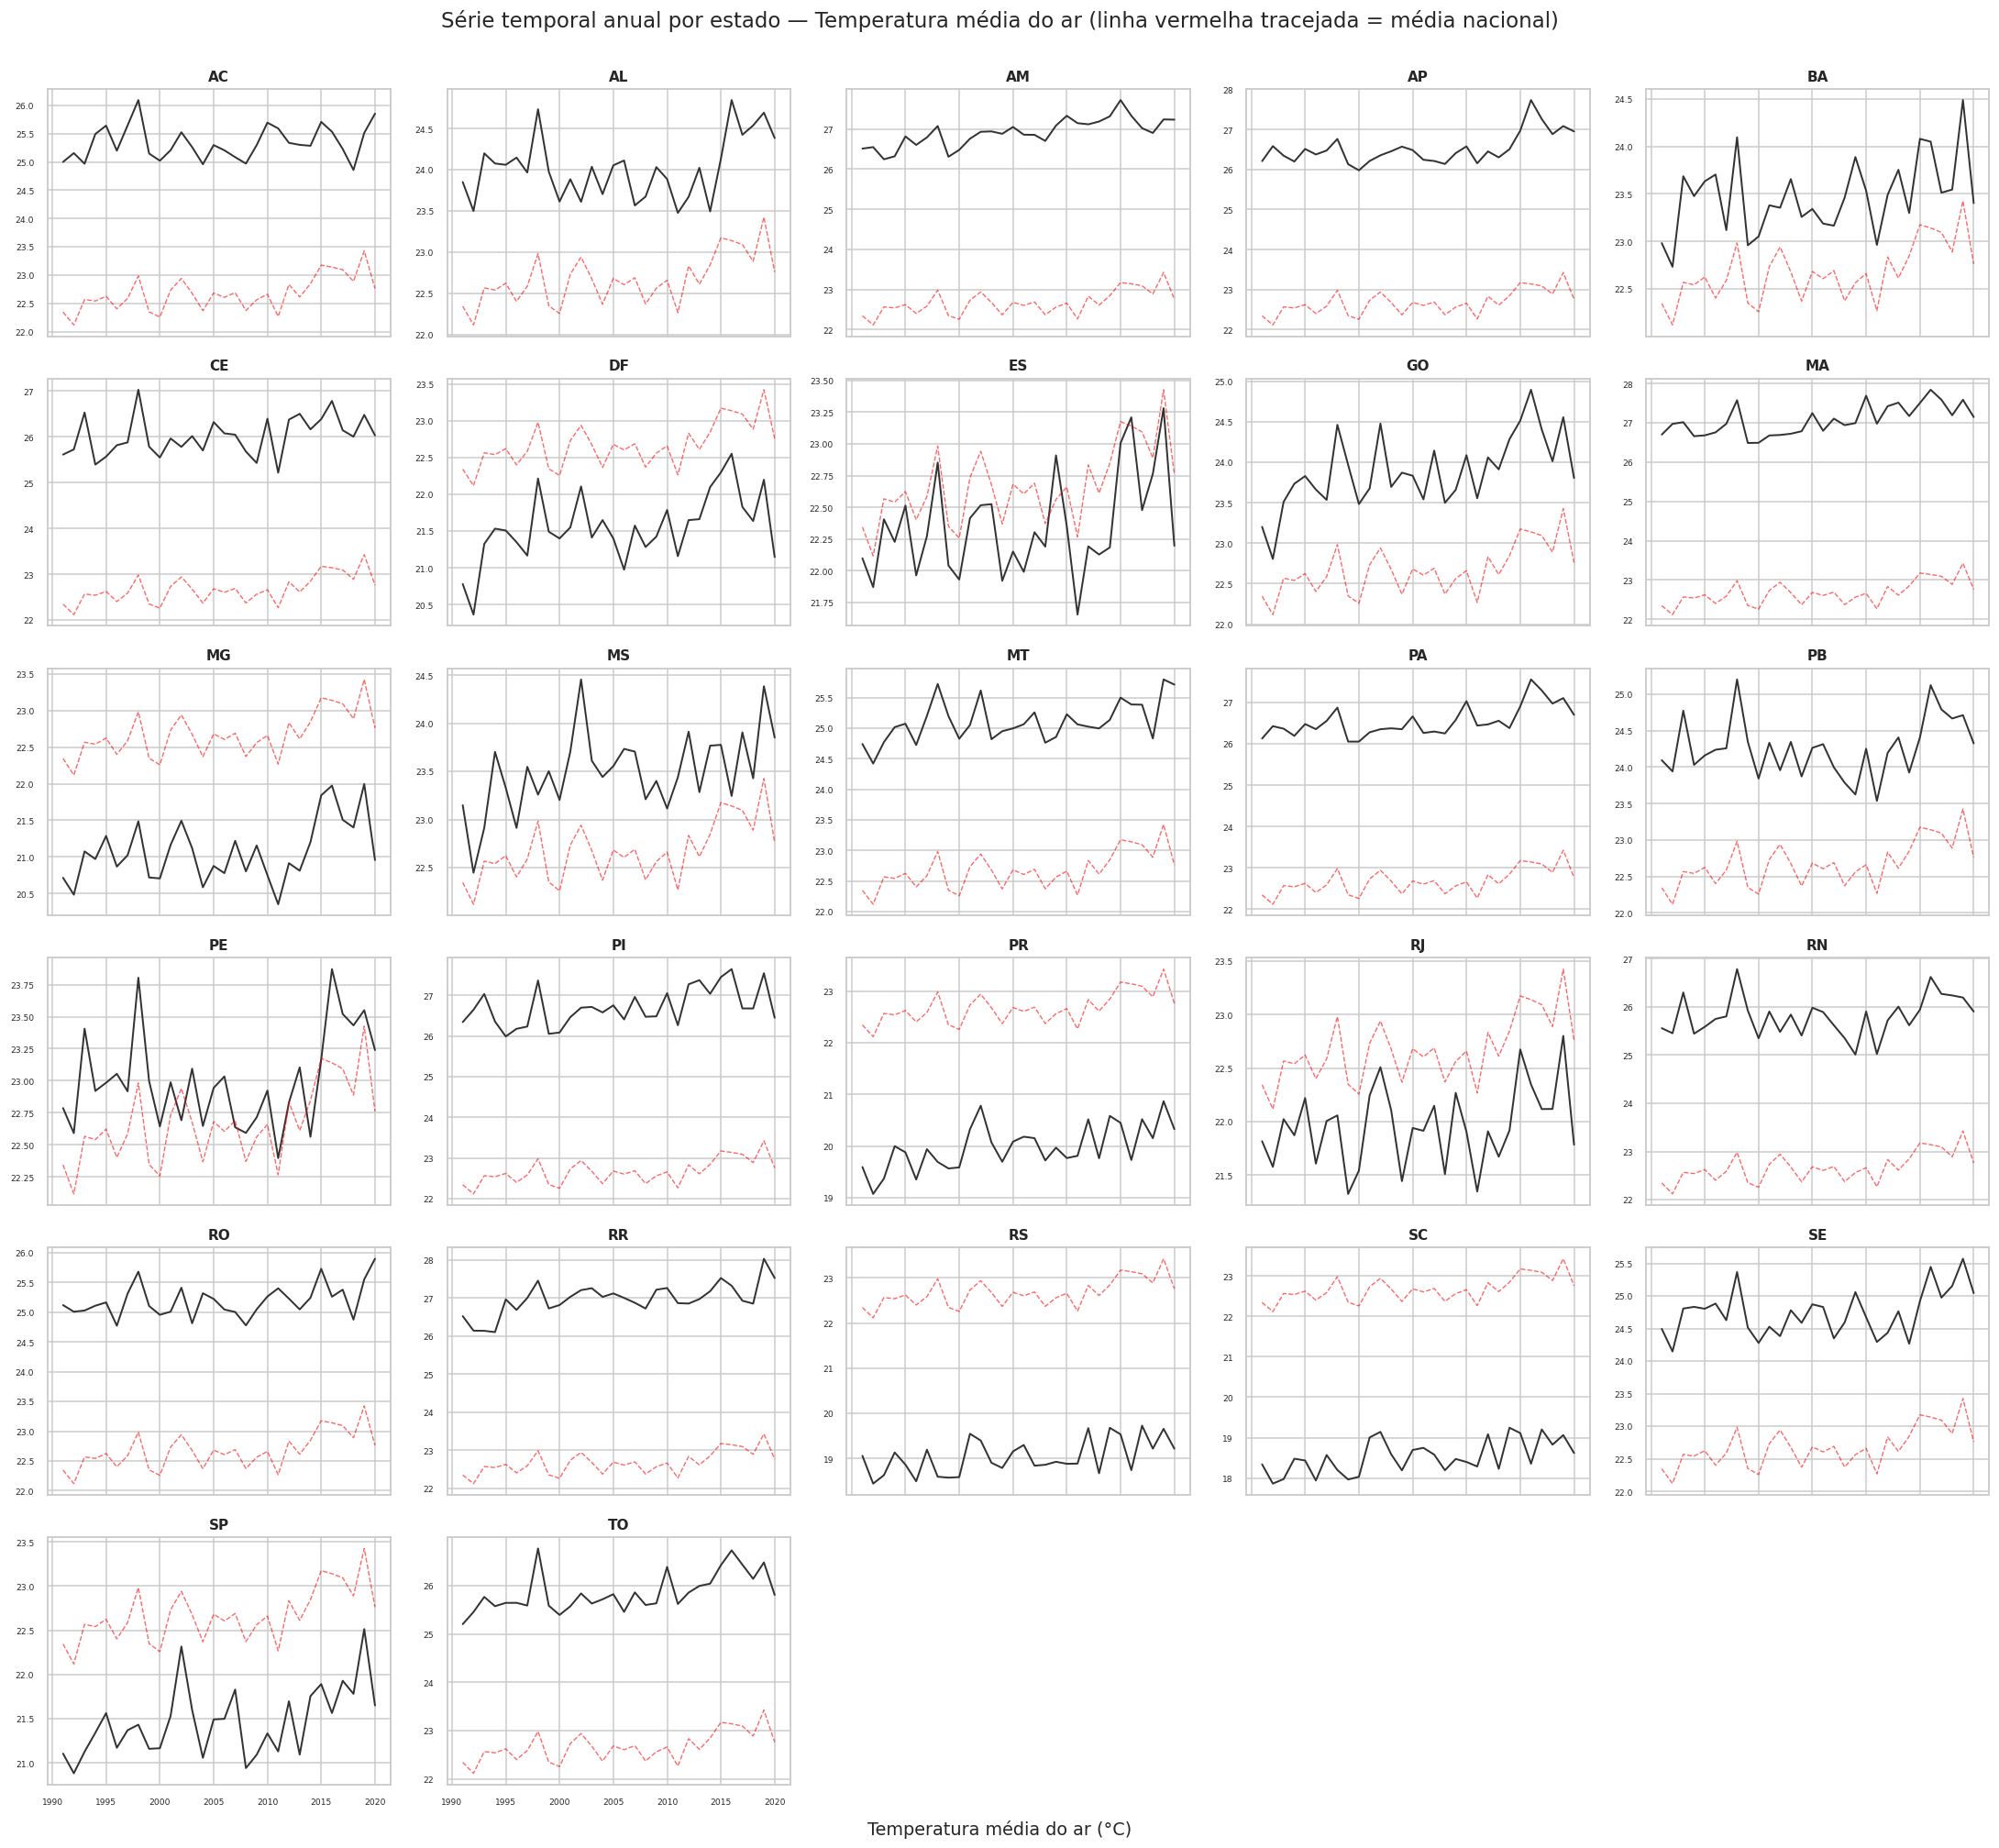

In [ ]:
def serie_temporal_por_uf(var):
    meta = VARS[var]
    serie_uf = agg_anual.groupby(["uf_sigla", "ano"])[var].mean().reset_index()
    serie_nacional = agg_anual.groupby("ano")[var].mean()

    ufs = sorted(serie_uf["uf_sigla"].unique())
    fig, axes = plt.subplots(6, 5, figsize=(20, 18), sharex=True)
    for ax, uf in zip(axes.flat, ufs):
        sub = serie_uf[serie_uf["uf_sigla"] == uf]
        ax.plot(sub["ano"], sub[var], color="#333333", linewidth=1.3)
        ax.plot(serie_nacional.index, serie_nacional.values, color="red",
                linewidth=0.9, linestyle="--", alpha=0.6)
        ax.set_title(uf, fontsize=10)
        ax.tick_params(labelsize=6)
    for ax in axes.flat[len(ufs):]:
        ax.axis("off")

    fig.suptitle(f"Série temporal anual por estado — {meta['label']} "
                 f"(linha vermelha tracejada = média nacional)", fontsize=15, y=1.0)
    fig.text(0.5, -0.005, f"{meta['label']} ({meta['unit']})", ha="center")
    fig.tight_layout()
    plt.show()

# Exemplo para Tmed — troque a variável para explorar pr / pet / deficit
serie_temporal_por_uf("Tmed")

### 6.4 Tendência nacional (Mann-Kendall + Sen's slope)

Teste não paramétrico de tendência (Mann-Kendall) e estimador robusto de magnitude
(Sen's slope), aplicados à série nacional anual de cada variável

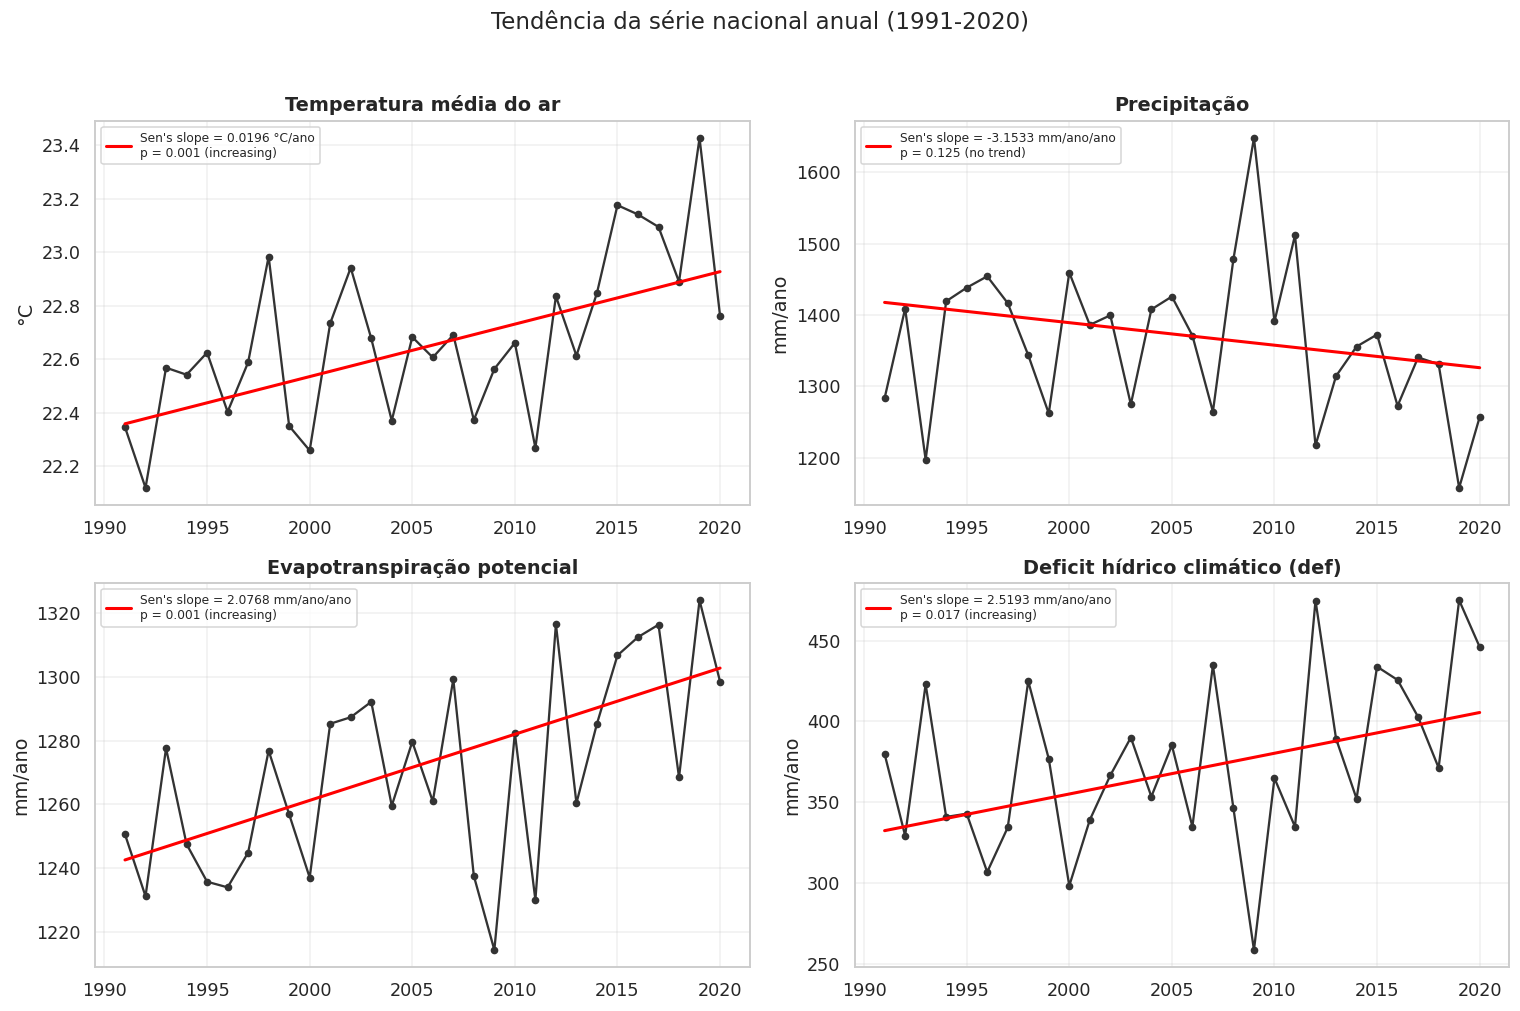

,variavel,tendencia,p_valor,sen_slope,tau
0,Tmed,increasing,0.0007,0.01961,0.439
1,pr,no trend,0.1249,-3.15327,-0.200
2,pet,increasing,0.0012,2.07676,0.421
3,deficit,increasing,0.0168,2.51929,0.310


In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
resultados_nacionais = []

for ax, var in zip(axes.flat, VAR_ORDER):
    meta = VARS[var]
    serie = agg_anual.groupby("ano")[var].mean()
    r = mk.original_test(serie.values)

    ax.plot(serie.index, serie.values, marker="o", markersize=4, color="#333333")
    tendencia = r.intercept + r.slope * (serie.index - serie.index[0])
    ax.plot(serie.index, tendencia, color="red", linewidth=2,
            label=f"Sen's slope = {r.slope:.4f} {meta['unit']}/ano\np = {r.p:.3f} ({r.trend})")
    ax.set_title(meta["label"])
    ax.set_ylabel(meta["unit"])
    ax.legend(fontsize=8, loc="best")
    ax.grid(alpha=0.3)

    resultados_nacionais.append(dict(
        variavel=var, tendencia=r.trend, p_valor=round(r.p, 4),
        sen_slope=round(r.slope, 5), tau=round(r.Tau, 3),
    ))

fig.suptitle("Tendência da série nacional anual (1991-2020)", fontsize=15, y=1.02)
fig.tight_layout()
plt.show()

pd.DataFrame(resultados_nacionais)

### 6.5 Tendência por estado

Aplicação do mesmo teste a cada UF individualmente, permitindo identificar quais
estados concentram os sinais de tendência mais fortes (aquecimento, redução de
precipitação, aumento do deficit hídrico etc.).

In [ ]:
registros = []
for uf in sorted(agg_anual["uf_sigla"].unique()):
    sub = agg_anual[agg_anual["uf_sigla"] == uf]
    for var in VAR_ORDER:
        serie = sub.groupby("ano")[var].mean()
        r = mk.original_test(serie.values)
        registros.append(dict(
            uf_sigla=uf, variavel=var, tendencia=r.trend,
            p_valor=round(r.p, 4), sen_slope=round(r.slope, 5), significativo=r.p < 0.05,
        ))

trend_uf = pd.DataFrame(registros)

print("Estados com tendência SIGNIFICATIVA (p < 0.05) por variável:\n")
for var in VAR_ORDER:
    sig = trend_uf[(trend_uf["variavel"] == var) & (trend_uf["significativo"])]
    sig = sig.sort_values("sen_slope", ascending=False)
    print(f"\n{VARS[var]['label']} — {len(sig)}/27 estados com tendência significativa")
    print(sig[["uf_sigla", "tendencia", "sen_slope", "p_valor"]].to_string(index=False))

trend_uf.to_csv("tendencias_mannkendall_por_uf.csv", index=False)

Estados com tendência SIGNIFICATIVA (p < 0.05) por variável:


Temperatura média do ar — 18/27 estados com tendência significativa
uf_sigla  tendencia  sen_slope  p_valor
      GO increasing    0.03024   0.0010
      PR increasing    0.02987   0.0007
      MA increasing    0.02980   0.0001
      AM increasing    0.02949   0.0000
      PI increasing    0.02947   0.0034
      RR increasing    0.02797   0.0019
      TO increasing    0.02584   0.0001
      SC increasing    0.02433   0.0034
      DF increasing    0.02361   0.0074
      RS increasing    0.02322   0.0074
      SP increasing    0.02225   0.0034
      PA increasing    0.02218   0.0007
      CE increasing    0.02195   0.0269
      MS increasing    0.02173   0.0067
      AP increasing    0.01979   0.0107
      MT increasing    0.01873   0.0074
      MG increasing    0.01662   0.0420
      RO increasing    0.01043   0.0457

Precipitação — 1/27 estados com tendência significativa
uf_sigla  tendencia  sen_slope  p_valor
      PA inc

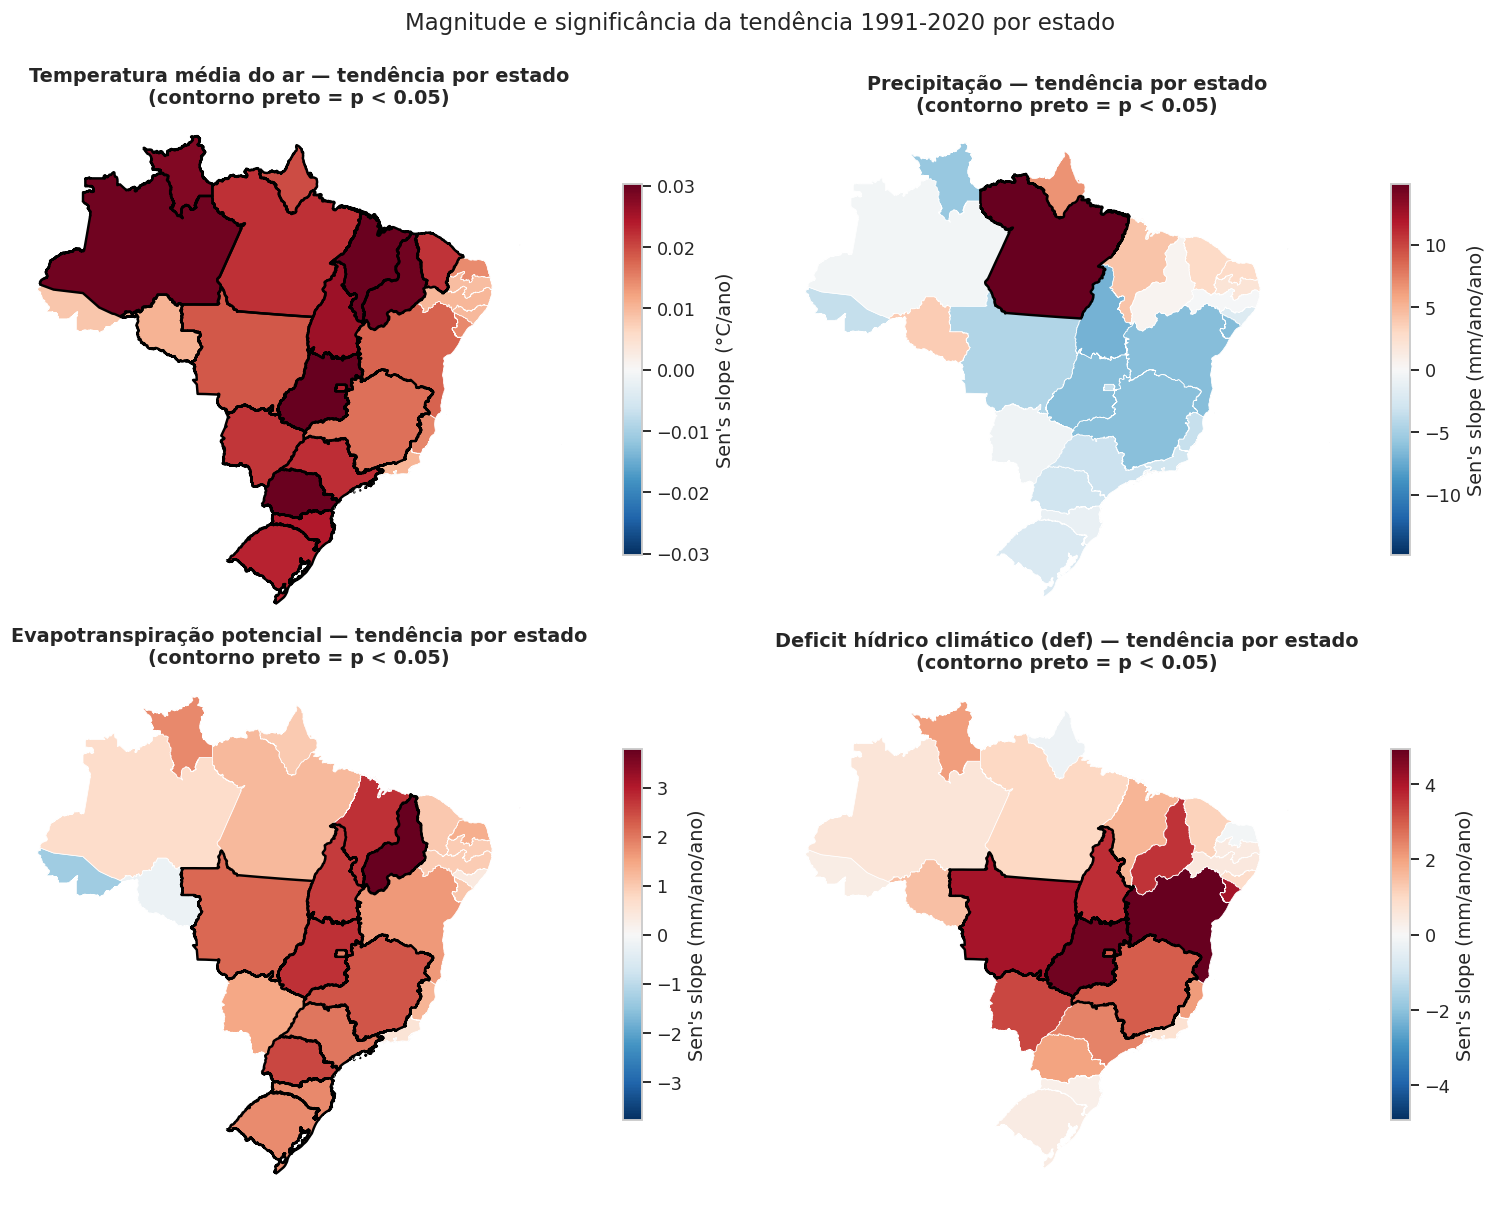

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 11))
for ax, var in zip(axes.flat, VAR_ORDER):
    meta = VARS[var]
    sub = trend_uf[trend_uf["variavel"] == var].merge(gdf_uf, on="uf_sigla", how="left")
    sub = gpd.GeoDataFrame(sub, geometry="geometry")

    vmax = sub["sen_slope"].abs().max()
    sub.plot(column="sen_slope", cmap="RdBu_r", ax=ax, legend=True,
              vmin=-vmax, vmax=vmax, edgecolor="white", linewidth=0.5,
              legend_kwds={"label": f"Sen's slope ({meta['unit']}/ano)", "shrink": 0.7})

    sig = sub[sub["significativo"]]
    if len(sig) > 0:
        sig.boundary.plot(ax=ax, edgecolor="black", linewidth=1.6)

    ax.set_title(f"{meta['label']} — tendência por estado\n(contorno preto = p < 0.05)")
    ax.axis("off")

fig.suptitle("Magnitude e significância da tendência 1991-2020 por estado", fontsize=15, y=1.0)
fig.tight_layout()
plt.show()

## 7. Síntese e exportação

Tabela consolidada com a caracterização climática de cada estado: normais climatológicas,
heterogeneidade interna (desvio-padrão) e tendência estatística — pronta para uso no
texto do artigo ou em material suplementar.

In [ ]:
sintese = estado_stats.copy()
for var in VAR_ORDER:
    tend = trend_uf[trend_uf["variavel"] == var].set_index("uf_sigla")
    sintese[f"{var}_tendencia"] = tend["tendencia"]
    sintese[f"{var}_sen_slope"] = tend["sen_slope"]
    sintese[f"{var}_signif"] = tend["significativo"]

sintese.to_csv("sintese_climatica_por_estado.csv")
sintese.to_excel("sintese_climatica_por_estado.xlsx")

normal.to_csv("normais_climatologicas_municipios.csv", index=False)

print("Arquivos exportados:")
print(" - sintese_climatica_por_estado.csv / .xlsx")
print(" - normais_climatologicas_municipios.csv")
print(" - tendencias_mannkendall_por_uf.csv")

sintese.head(10)

Arquivos exportados:
 - sintese_climatica_por_estado.csv / .xlsx
 - normais_climatologicas_municipios.csv
 - tendencias_mannkendall_por_uf.csv


,Tmed_mean,Tmed_std,Tmed_min,Tmed_max,pr_mean,pr_std,pr_min,pr_max,pet_mean,pet_std,...,Tmed_signif,pr_tendencia,pr_sen_slope,pr_signif,pet_tendencia,pet_sen_slope,pet_signif,deficit_tendencia,deficit_sen_slope,deficit_signif
uf_sigla,,,,,,,,,,,,,,,,,,,,,
MA,27.07,0.75,24.59,28.44,1576.21,391.22,972.70,2956.07,1417.23,64.37,...,True,no trend,4.17224,False,no trend,2.77039,False,no trend,1.68743,False
RR,26.98,0.99,24.29,28.17,2054.63,255.58,1663.77,2559.80,1321.91,50.98,...,True,no trend,-5.56667,False,no trend,1.82667,False,no trend,2.07467,False
AM,26.91,0.71,25.05,27.91,2477.75,338.94,2095.90,3680.47,1124.49,63.65,...,True,no trend,-0.39862,False,no trend,0.68935,False,no trend,0.65269,False
PI,26.71,0.81,24.18,28.42,958.28,307.84,417.10,1632.57,1544.33,41.22,...,True,no trend,0.36719,False,increasing,3.77819,True,no trend,3.57309,False
PA,26.54,0.52,24.04,27.60,2353.17,480.83,1524.87,3556.13,1303.37,48.64,...,True,increasing,14.82887,True,no trend,1.21267,False,no trend,1.00074,False
AP,26.52,0.53,25.62,27.19,2353.99,178.71,1994.73,2721.23,1348.70,34.32,...,True,no trend,6.68229,False,no trend,0.99318,False,no trend,-0.24732,False
CE,26.01,1.47,21.06,27.90,891.33,200.68,523.13,1512.00,1553.97,75.68,...,True,no trend,3.01087,False,no trend,1.02288,False,no trend,1.13086,False
TO,25.85,0.63,23.63,27.16,1563.03,135.84,1210.73,1824.73,1366.56,46.19,...,True,no trend,-6.98201,False,increasing,2.63141,True,increasing,3.65198,True
RN,25.79,1.04,22.34,27.98,760.35,222.31,451.90,1438.63,1528.04,87.22,...,False,no trend,2.83171,False,no trend,1.36061,False,no trend,-0.14198,False
